In [381]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'monospace'

#### Functions

In [382]:
def rms_to_amp(rms):
    return rms * np.sqrt(2)

def lin_to_dB(x):
    return 20 * np.log10(x)

def deg_to_rad(deg):
    return (np.pi / 180) * deg

#### Experiment 1 - plots

In [383]:
# Raw data
df1 = pd.read_csv("bandpass_characterization_data.csv", delimiter=",")

freq = df1["freq_Hz"].to_numpy()
print(freq[-1])
vol_max = df1["Vmax_V"].to_numpy()
vol_min = df1["Vmin_V"].to_numpy()
phase_deg = df1["phase_deg"].to_numpy()

40000.0


In [384]:
# Array conversions
dc_offset = (vol_max + vol_min) / 2
amp = (vol_max - vol_min) / 2
amp_dB = lin_to_dB(amp)
#phase_rad = np.unwrap(deg_to_rad(phase_deg)) # Unwrapped

def phase_unwrapper(phase_deg):
    diffs = np.diff(phase_deg)
    jumps = np.where(np.abs(diffs) > 180)[0]
    unwrapped = phase_deg.copy()
    for jump in jumps:
        if diffs[jump] > 0:
            unwrapped[jump + 1:] -= 360
        else:
            unwrapped[jump + 1:] += 360
    return unwrapped

phase_deg_unwrapped = phase_unwrapper(phase_deg)

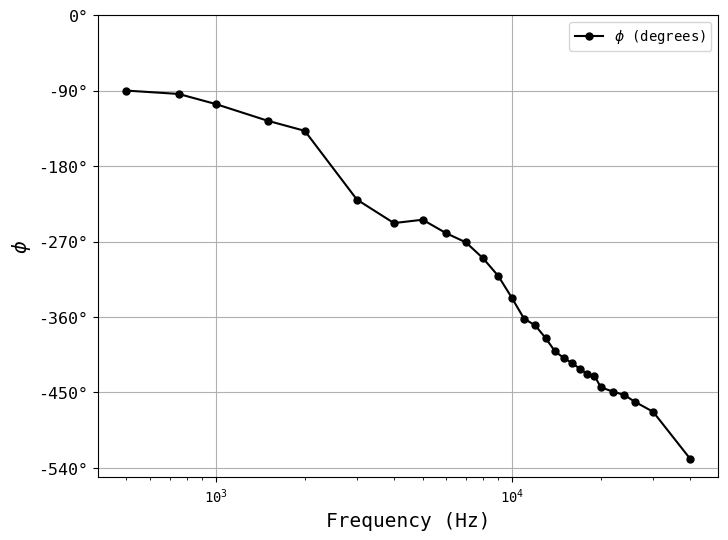

In [385]:

# Plot the phase in degrees, but unwrapped
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(freq, phase_deg_unwrapped, 'o-', ms = 5, color = 'k', label=r'$\phi$ (degrees)')
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel(r'$\phi$', fontsize=14)

#Set yticks to be every 90 degrees, and y-tick labels in degrees
ax.set_yticks(np.arange(-540, 90, 90))
ax.set_yticklabels([f"{int(tick)}°" for tick in np.arange(-540, 90, 90)], fontsize=12)

ax.grid(True)
ax.legend()
plt.show()

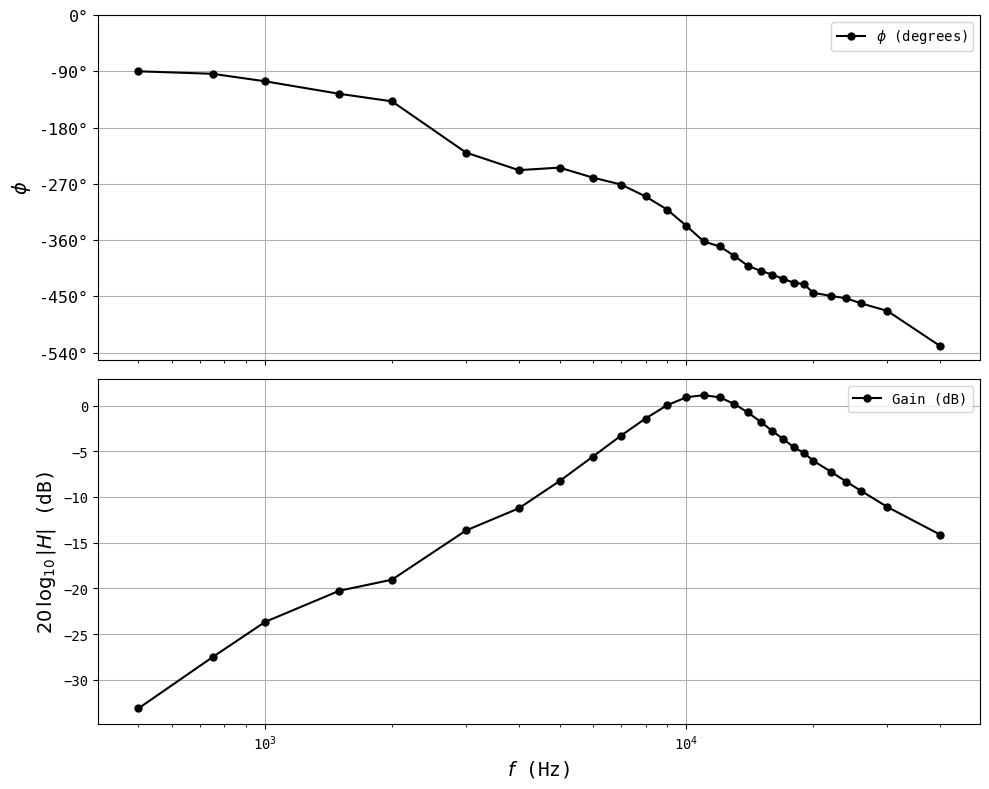

In [ ]:
# Plotting amplitude dB

fig, ax = plt.subplots(2,1, figsize=(10, 8), sharex=True)

ax[1].plot(freq, phase_deg_unwrapped, 'o-', ms = 5, color = 'k', label=r'$\phi$ (degrees)')
ax[1].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)', fontsize=14)
ax[1].set_ylabel(r'$\phi$', fontsize=14)

#Set yticks to be every 90 degrees, and y-tick labels in degrees
ax[1].set_yticks(np.arange(-540, 90, 90))
ax[1].set_yticklabels([f"{int(tick)}°" for tick in np.arange(-540, 90, 90)], fontsize=12)

ax[1].grid(True)
ax[1].legend()

ax[0].plot(freq, amp_dB, 'o-', ms = 5, color='k', label = 'Gain (dB)')
ax[0].set_xlabel(r"$f$ (Hz)", fontsize=14)
ax[0].set_ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
ax[0].set_xscale('log')
ax[0].grid(True)
ax[0].legend()

plt.tight_layout()
plt.show()

In [387]:
def bandpass_model(f, f_minus, f_plus, G, k):
    H = G*(f/f_minus)**2 / ((1+(f/f_minus)**2)*1+(f/f_plus)**2)
    return 20 * np.log10(H) + k

In [388]:
y_errs = np.full_like(amp_dB, 0.13) # Assuming a constant error of 0.5 dB for all points
#Fit with minuit chi2: 

mfit = cost.LeastSquares(freq[6:], amp_dB[6:] , y_errs[6:], bandpass_model)
# Initial guesses: f_minus = 1kHz, f_plus = 100kHz, G = 1, k = 0
minuit_bandpass = Minuit(mfit, f_minus=1590, f_plus=15900, G=100, k=0)
minuit_bandpass.migrad()

C:\Users\asker\AppData\Local\Temp\ipykernel_16932\646092403.py:3: RuntimeWarning: invalid value encountered in log10
  return 20 * np.log10(H) + k


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.378e+04 (χ²/ndof = 1320.9)│              Nfcn = 352              │
│ EDM = 4.64e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ f_minus │   25e3    │    4e3    │            │            │         │         │       │
│ 1 │ f_plus  │  -2.40e3  │  0.05e3   │            │            │         │         │       │
│ 2 │ G       │    120    │    24     │            │            │         │         │       │
│ 3 │ k       │   -4.9    │    3.2    │            │            │         │         │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬─────────────────────────────────────┐
│         │  f_minus   f_plus        G        k │
├─────────┼─────────────────────────────────────┤
│ f_minus │ 1.39e+07   11.6e3       -0  9.666e3 │
│  f_plus │   11.6e3 2.71e+03       -0       26 │
│       G │       -0       -0      594      -43 │
│       k │  9.666e3       26      -43     9.99 │
└─────────┴─────────────────────────────────────┘

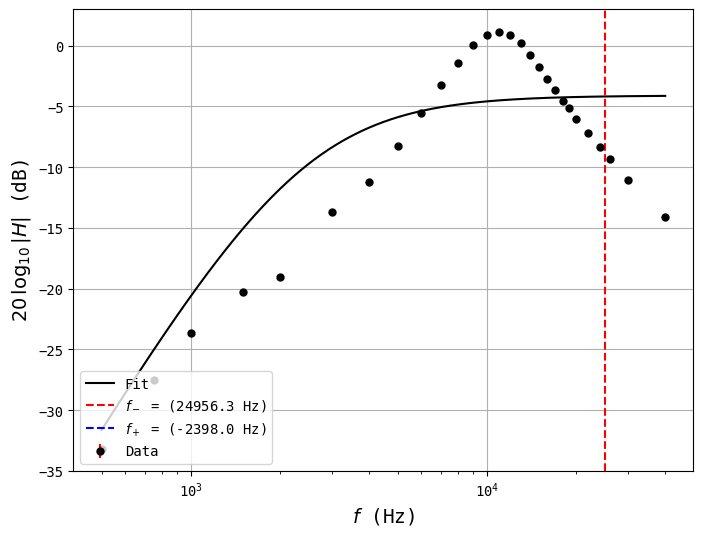

In [389]:
f_minus = minuit_bandpass.values['f_minus']
f_plus = minuit_bandpass.values['f_plus']
G = minuit_bandpass.values['G']
k = minuit_bandpass.values['k']

#plot:
f_linspace = np.linspace(np.min(freq), np.max(freq), 1000)
func_values = bandpass_model(f_linspace, f_minus, f_plus, G, k)
plt.figure(figsize=(8, 6))
plt.errorbar(freq, amp_dB, yerr=y_errs, fmt='o', ms = 5, color='k', ecolor='r', label='Data')
plt.plot(f_linspace, func_values, linestyle='-', color='k', label=f'Fit')
plt.axvline(f_minus, color='r', linestyle='--', label=f'$f_-$ = ({f_minus:.1f} Hz)')
plt.axvline(f_plus, color='b', linestyle='--', label=f'$f_+$ = ({f_plus:.1f} Hz)')  
plt.xlabel(r"$f$ (Hz)", fontsize=14)
plt.ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
plt.xscale('log')
plt.grid(True)
plt.legend(loc = 'lower left');


#### Experiment 2 - plots

In [390]:
# Raw data
df2 = pd.read_csv("lowpass_characterization_data.csv", delimiter=",")

freq_detuning = df2["freq_detuning_Hz"].to_numpy()
amp_rms = df2["amplitude_rms_V"].to_numpy()

In [391]:
# Array conversions
amp_dB = lin_to_dB(rms_to_amp(amp_rms))
print("Frequencies (Hz):", freq_detuning)
print("Amplitudes (dB):", amp_dB)

Frequencies (Hz): [   1    2    3    4    5    6    7    8    9   10   20   30   40   50
   60   70   80   90  100  200  300  400  500  600  700  800  900 1000
 2000 3000]
Amplitudes (dB): [  1.39395454   1.37090669   1.38976857   1.39290823   1.38976857
   1.39081525   1.40650036   1.41485419   1.40754503   1.41485419
   1.36251047   1.26324208   1.12621756   0.99247712   0.76377101
   0.54158424   0.30645254   0.04647024  -0.22783727  -3.11516106
  -5.70348184  -7.81694306  -9.57573819 -11.05639624 -12.31962484
 -13.45630139 -14.44112449 -15.34117403 -21.00288905 -24.12064651]


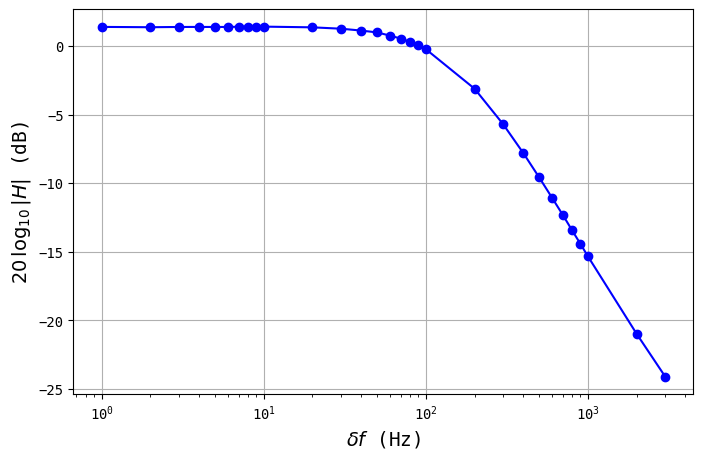

In [392]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(freq_detuning, amp_dB, marker='o', linestyle='-', color='b')
plt.xlabel(r"$\delta f$ (Hz)", fontsize=14)
plt.ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
plt.xscale('log')
plt.grid(True)
plt.show()

## Fitting

In [393]:
def constant(x, c):
    return c

In [394]:
lin_amps = amp_dB[:10]
lin_freqs = freq_detuning[:10]

In [395]:
#Use Scipy to fit a constant to the linear region
popt, pcov = curve_fit(constant, lin_freqs, lin_amps)
lin_resvals = lin_amps - constant(lin_freqs, *popt)
errors = np.array(np.std(lin_resvals)*np.ones_like(amp_dB))*10
print(f"Estimated noise level (std of residuals): {np.std(lin_resvals):.2f} dB")

Estimated noise level (std of residuals): 0.01 dB


In [396]:
def low_pass_model(f, f_c, k):
    return 20 * np.log10(1 / np.sqrt(1 + (f / f_c)**2)) + k

#Do chi2 fit using iminuit
f_c_theory = 1/((2*np.pi*10e3 * 100e-9)) # Initial guess (R10=10k, C7=100nF)

mfit = cost.LeastSquares(freq_detuning, amp_dB , errors, low_pass_model)
minuit_pendul = Minuit(mfit, f_c = f_c_theory, k = popt[0])
minuit_pendul.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 25.88 (χ²/ndof = 0.9)      │              Nfcn = 35               │
│ EDM = 7.18e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ f_c  │   148.9   │    1.0    │            │            │         │         │       │
│ 1 │ k    │   1.409   │   0.032   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │     f_c       k │
├─────┼─────────────────┤
│ f_c │   0.949 -0.0211 │
│   k │ -0.0211 0.00103 │
└─────┴─────────────────┘

In [397]:
f_c = minuit_pendul.values['f_c']
f_c_err = minuit_pendul.errors['f_c']
k = minuit_pendul.values['k']

chi2_val = minuit_pendul.fval
dof = len(freq_detuning) - len(minuit_pendul.values)
chi2p_val = 1 - stats.chi2.cdf(chi2_val, dof)
print(f"Fitted cutoff frequency: {f_c:.1f} Hz")
print(f"Chi2: {chi2_val:.2f}, dof: {dof}, p-value: {chi2p_val} i.e. ok fit, but i've multiplied the errors by 10.")

Fitted cutoff frequency: 148.9 Hz
Chi2: 25.88, dof: 28, p-value: 0.579884651557999 i.e. ok fit, but i've multiplied the errors by 10.


In [398]:
f_linspace = np.linspace(np.min(freq_detuning), np.max(freq_detuning), 1000)
func_values = low_pass_model(f_linspace, f_c, k)

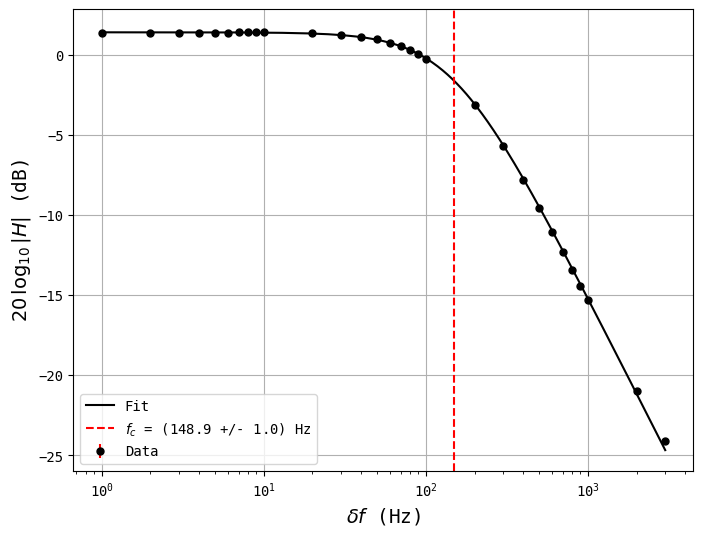

In [399]:
#plot the entire thing: 
plt.figure(figsize=(8, 6))
plt.errorbar(freq_detuning, amp_dB, yerr=errors, fmt='o', ms = 5, color='k', ecolor='r', label='Data')
plt.plot(f_linspace, func_values, linestyle='-', color='k', label=f'Fit')
plt.axvline(f_c, color='r', linestyle='--', label=f'$f_c$ = ({f_c:.1f} +/- {f_c_err:.1f}) Hz')
plt.xlabel(r"$\delta f$ (Hz)", fontsize=14)
plt.ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
plt.xscale('log')
plt.grid(True)
plt.legend(loc = 'lower left');

In [400]:
print(f_c*1e-3, f_c_err*1e-3)

0.1488897339098 0.000974045634038921
